# DRL05 Continuous Control

### Lab Description

This laboratory develops two continuous-control algorithms from first principles. We begin with **Proximal Policy Optimization (PPO)** on Gymnasium `Pendulum-v1`. Its three observations and one bounded torque make the clipped policy objective, generalized advantage estimation, and continuous action distribution easy to inspect.

We then develop **Soft Actor-Critic (SAC)** in detail on the DeepMind Control Suite's `walker-run` task. Starting from the maximum-entropy objective, we derive the soft Bellman backup, explain clipped double-Q learning and target critics, connect reparameterized actions to the policy gradient, learn the entropy temperature, and map each equation to a complete replay-based update. The default SAC experiment always runs the full **1,000,000 environment steps**.

Gymnasium and MuJoCo environment stepping remain sequential CPU work. Every policy/value forward pass used for collection, every replay batch, every loss, and every optimizer update runs through PyTorch on an AMD GPU with ROCm. Training stops with an error if that device is unavailable; there is no silent CPU fallback. Quantitative evaluation reports only each environment's original return. Separate deterministic evaluation rollouts are saved as animated GIFs with `loop=0`, so they replay continuously in the notebook.

#### Recommended Hardware

AMD Ryzen™ AI Halo Processors (for example, Ryzen™ AI Max+ PRO 395 or Ryzen™ AI Max 390) or an AMD GPU supported by ROCm™.

#### Software Environment

OS: Ubuntu 24.04 LTS  
Python 3.10–3.12 with Gymnasium, DeepMind Control Suite, MuJoCo, PyTorch for ROCm, NumPy, Matplotlib, ImageIO, Pillow, and Pygame in the [AUP Learning Cloud](https://amdresearch.github.io/aup-learning-cloud/installation/quick-start.html) environment.

## Goals

- Inspect bounded continuous observation and action interfaces
- Establish native-return random-action baselines
- Build a tanh-squashed Gaussian policy with correct action scaling
- Derive PPO's clipped surrogate objective and generalized advantage estimates
- Train PPO on `Pendulum-v1` with minibatch updates on an AMD GPU
- Contrast on-policy PPO with off-policy SAC
- Derive the soft value, Bellman target, critic, actor, and temperature objectives
- Implement uniform replay, twin critics, target critics, and Polyak averaging
- Train SAC for one million steps on DeepMind Control `walker-run`
- Distinguish episode reset boundaries from value-bootstrap boundaries
- Evaluate deterministic policies with native returns and looping GIF rollouts


## 1. Setup

The setup cell installs missing visualization packages and enforces the `dm_control==1.0.28` / `mujoco==3.3.0` pair used by this tutorial. PyTorch is deliberately excluded: a generic wheel can replace the ROCm build. If PyTorch or an AMD ROCm device is missing, the notebook stops with instructions to use the AUP Learning Cloud ROCm image.

The portable default keeps MuJoCo OpenGL disabled and draws Walker's exact capsule geometry from simulator state for the evaluation GIF. An image that includes Mesa/EGL can opt into MuJoCo's native tracked camera by setting `MUJOCO_GL=egl` before starting a fresh kernel. Pendulum uses Gymnasium's native RGB renderer in either case.


In [1]:
import importlib.metadata
import importlib.util
import os
import site
import subprocess
import sys


os.environ.setdefault("SDL_VIDEODRIVER", "dummy")
os.environ.setdefault("MUJOCO_GL", "disable")

required_packages = {
    "gymnasium": "gymnasium",
    "imageio": "imageio",
    "matplotlib": "matplotlib",
    "PIL": "Pillow",
    "pygame": "pygame",
}
missing_packages = [
    package_name
    for module_name, package_name in required_packages.items()
    if importlib.util.find_spec(module_name) is None
]

try:
    dm_control_version = importlib.metadata.version("dm_control")
except importlib.metadata.PackageNotFoundError:
    dm_control_version = None
if dm_control_version != "1.0.28":
    missing_packages.append("dm_control==1.0.28")

try:
    mujoco_version = importlib.metadata.version("mujoco")
except importlib.metadata.PackageNotFoundError:
    mujoco_version = None
if mujoco_version != "3.3.0":
    missing_packages.append("mujoco==3.3.0")

if missing_packages:
    print("Installing missing packages:", ", ".join(missing_packages))
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--user",
            "--quiet",
            "--no-warn-script-location",
            *missing_packages,
        ]
    )
    site.addsitedir(site.getusersitepackages())

if importlib.util.find_spec("torch") is None:
    raise RuntimeError(
        "PyTorch is missing. Start this notebook with the AUP Learning "
        "Cloud ROCm image instead of installing a generic PyTorch wheel."
    )

import copy
import math
import random
import time
from dataclasses import asdict, dataclass
from pathlib import Path

import gymnasium as gym
import imageio.v2 as imageio
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from dm_control import suite
from IPython.display import Image as NotebookImage
from IPython.display import display
from PIL import Image as PILImage
from PIL import ImageDraw
from torch.distributions import Normal

torch.set_num_threads(min(8, os.cpu_count() or 1))

print("Python:", sys.version.split()[0])
print("Gymnasium:", gym.__version__)
print("dm_control:", importlib.metadata.version("dm_control"))
print("MuJoCo:", importlib.metadata.version("mujoco"))
print("PyTorch:", torch.__version__)
print("ROCm/HIP:", torch.version.hip or "not available")
print("NumPy:", np.__version__)
print("Matplotlib:", matplotlib.__version__)
print("ImageIO:", importlib.metadata.version("imageio"))
print("MuJoCo GL backend:", os.environ["MUJOCO_GL"])


Python: 3.12.3
Gymnasium: 1.3.0
dm_control: 1.0.28
MuJoCo: 3.3.0
PyTorch: 2.9.1+rocm7.13.0
ROCm/HIP: 7.13.99004-3309c6114a
NumPy: 2.4.6
Matplotlib: 3.11.0
ImageIO: 2.37.4
MuJoCo GL backend: disable


In [2]:
SEED = 17
ARTIFACT_DIR = Path("artifacts") / "DRL05"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

ROCM_AVAILABLE = bool(
    torch.cuda.is_available() and torch.version.hip is not None
)
ROCM_DEVICE = torch.device("cuda:0") if ROCM_AVAILABLE else None
if ROCM_AVAILABLE:
    torch.cuda.manual_seed_all(SEED)


def require_amd_gpu(device=None):
    if not ROCM_AVAILABLE:
        raise RuntimeError(
            "PPO and SAC training require the AUP Learning Cloud ROCm "
            "image and a visible AMD GPU. CPU fallback is disabled."
        )
    resolved_device = (
        ROCM_DEVICE if device is None else torch.device(device)
    )
    if resolved_device.type != "cuda":
        raise RuntimeError(
            "Training must use the AMD ROCm GPU; "
            f"received device={resolved_device}."
        )
    return resolved_device


def model_device(model):
    return next(model.parameters()).device


def require_models_on_amd_gpu(*models):
    device = require_amd_gpu()
    for model in models:
        if model_device(model) != device:
            raise RuntimeError(
                f"{type(model).__name__} is on {model_device(model)}, "
                f"not {device}."
            )
    return device


DEVICE = require_amd_gpu()
properties = torch.cuda.get_device_properties(DEVICE)
print("Neural-training device:", DEVICE)
print("Accelerator backend: ROCm/HIP")
print("AMD GPU:", torch.cuda.get_device_name(DEVICE))
print(f"Visible GPU memory: {properties.total_memory / 2**30:.1f} GiB")
print("Artifacts:", ARTIFACT_DIR.resolve())

# Execute one real ROCm kernel now instead of trusting device discovery alone.
gpu_probe = torch.randn(512, 512, device=DEVICE)
gpu_probe_checksum = (gpu_probe @ gpu_probe.T).mean()
torch.cuda.synchronize(DEVICE)
assert gpu_probe_checksum.isfinite()
del gpu_probe, gpu_probe_checksum
print("ROCm tensor-operation probe: passed")


Neural-training device: cuda:0
Accelerator backend: ROCm/HIP
AMD GPU: Radeon 8060S Graphics
Visible GPU memory: 64.0 GiB
Artifacts: /home/jovyan/work/artifacts/DRL05
ROCm tensor-operation probe: passed


## 2. Two Continuous-Control Environments

A continuous policy produces real-valued actions and must respect every actuator bound. The two tasks increase dimensionality while retaining compact vector observations.

| Task | Observation | Action | Episode limit | Native reward and return |
|---|---:|---:|---:|---:|
| Gymnasium Pendulum | 3 | 1 in $[-2,2]$ | 200 steps | reward $\leq 0$; return is the 200-step sum |
| DeepMind Control Walker Run | 24 | 6 in $[-1,1]$ | 1,000 steps | reward in $[0,1]$; return in $[0,1000]$ |

Pendulum observes cosine, sine, and angular velocity. Walker initially exposes an ordered mapping with `orientations`, `height`, and `velocity`; the adapter concatenates them into 24 `float32` features. Its six actions coordinate the hip, knee, and ankle actuators on both legs.

Walker Run uses a 0.025-second control timestep and rewards both standing and forward speed toward 8 m/s. The native task combines these terms as `stand_reward * (5 * move_reward + 1) / 6`, without any tutorial-side reward shaping.


In [3]:
def make_pendulum(seed, render_mode=None):
    env = gym.make("Pendulum-v1", render_mode=render_mode)
    env.action_space.seed(seed)
    return env


class WalkerRunEnvironment:
    # Adapter preserving dm_control's bootstrap discount and render access.

    def __init__(self, seed):
        self.environment = suite.load(
            domain_name="walker",
            task_name="run",
            task_kwargs={"random": int(seed)},
            environment_kwargs={"flat_observation": True},
        )
        self._action_spec = self.environment.action_spec()
        self.action_low = np.broadcast_to(
            self._action_spec.minimum, self._action_spec.shape
        ).astype(np.float32, copy=True)
        self.action_high = np.broadcast_to(
            self._action_spec.maximum, self._action_spec.shape
        ).astype(np.float32, copy=True)
        self.rng = np.random.default_rng(seed)
        self._native_rendering = os.environ.get("MUJOCO_GL") != "disable"
        self.render_backend = (
            "MuJoCo RGB" if self._native_rendering else "portable 2-D"
        )

    @staticmethod
    def _observation(time_step):
        return np.asarray(
            time_step.observation["observations"], dtype=np.float32
        )

    def reset(self):
        return self._observation(self.environment.reset())

    def sample_action(self):
        return self.rng.uniform(
            self.action_low, self.action_high
        ).astype(self._action_spec.dtype)

    def step(self, action):
        action = np.clip(
            np.asarray(action), self.action_low, self.action_high
        ).astype(self._action_spec.dtype, copy=False)
        time_step = self.environment.step(action)
        observation = self._observation(time_step)
        reward = float(time_step.reward)
        episode_done = bool(time_step.last())
        bootstrap_discount = float(time_step.discount)
        return observation, reward, episode_done, bootstrap_discount

    def _render_kinematic(self, height, width):
        physics = self.environment.physics
        geom_names = (
            "left_thigh",
            "left_leg",
            "left_foot",
            "right_thigh",
            "right_leg",
            "right_foot",
            "torso",
        )
        capsules = {}
        for name in geom_names:
            geom_id = physics.model.name2id(name, "geom")
            center = np.asarray(physics.data.geom_xpos[geom_id]).copy()
            rotation = np.asarray(
                physics.data.geom_xmat[geom_id]
            ).reshape(3, 3)
            axis = rotation[:, 2]
            radius = float(physics.model.geom_size[geom_id, 0])
            half_length = float(physics.model.geom_size[geom_id, 1])
            capsules[name] = (
                center - axis * half_length,
                center + axis * half_length,
                radius,
            )

        torso_id = physics.model.name2id("torso", "geom")
        center_x = float(physics.data.geom_xpos[torso_id, 0])
        x_min, x_max = center_x - 1.55, center_x + 1.55
        z_min, z_max = -0.12, 2.15

        def pixel(point):
            x, z = map(float, point)
            px = int((x - x_min) / (x_max - x_min) * (width - 1))
            py = int((z_max - z) / (z_max - z_min) * (height - 1))
            return px, py

        canvas = PILImage.new("RGB", (width, height), (239, 246, 252))
        draw = ImageDraw.Draw(canvas)
        floor_y = pixel((center_x, 0.0))[1]
        draw.rectangle((0, floor_y, width, height), fill=(224, 224, 218))
        draw.line((0, floor_y, width, floor_y), fill=(90, 90, 90), width=2)
        grid_x = math.floor(x_min / 0.5) * 0.5
        while grid_x <= x_max:
            px, _ = pixel((grid_x, 0.0))
            draw.line((px, floor_y, px, height), fill=(196, 196, 190))
            grid_x += 0.5

        for name, (start, end, radius) in capsules.items():
            if name.startswith("left"):
                color = (52, 112, 176)
            elif name.startswith("right"):
                color = (205, 82, 70)
            else:
                color = (45, 45, 48)
            start_pixel = pixel(start[[0, 2]])
            end_pixel = pixel(end[[0, 2]])
            pixel_radius = max(
                3,
                int(radius / (x_max - x_min) * width),
            )
            draw.line(
                (start_pixel, end_pixel),
                fill=color,
                width=2 * pixel_radius,
            )
            for px, py in (start_pixel, end_pixel):
                draw.ellipse(
                    (
                        px - pixel_radius,
                        py - pixel_radius,
                        px + pixel_radius,
                        py + pixel_radius,
                    ),
                    fill=color,
                )
        return np.asarray(canvas)

    def render(self, height=240, width=320, camera_id="side"):
        if self._native_rendering:
            try:
                return self.environment.physics.render(
                    height=height,
                    width=width,
                    camera_id=camera_id,
                ).copy()
            except Exception as error:
                print(
                    "Native MuJoCo rendering unavailable; using the "
                    f"portable 2-D view ({type(error).__name__})."
                )
                self._native_rendering = False
                self.render_backend = "portable 2-D"
        return self._render_kinematic(height, width)

    def close(self):
        close = getattr(self.environment, "close", None)
        if close is not None:
            close()
        self.environment = None


pendulum_probe = make_pendulum(SEED)
pendulum_observation, _ = pendulum_probe.reset(seed=SEED)
print("Pendulum observation:", pendulum_observation)
print("Pendulum observation space:", pendulum_probe.observation_space)
print("Pendulum action space:", pendulum_probe.action_space)
pendulum_probe.close()

raw_walker_probe = suite.load(
    "walker", "run", task_kwargs={"random": SEED}
)
raw_walker_step = raw_walker_probe.reset()
print("Walker Run raw observation fields:")
for name, value in raw_walker_step.observation.items():
    print(f"  {name:12s} {np.asarray(value).shape}")
raw_walker_probe = None

walker_probe = WalkerRunEnvironment(SEED)
walker_observation = walker_probe.reset()
print("Walker Run flattened observation shape:", walker_observation.shape)
print("Walker Run action shape:", walker_probe.action_low.shape)
print(
    "Walker Run action bounds:",
    float(walker_probe.action_low.min()),
    "to",
    float(walker_probe.action_high.max()),
)
walker_probe.close()

assert pendulum_observation.shape == (3,)
assert walker_observation.shape == (24,)
assert walker_probe.action_low.shape == (6,)


Pendulum observation: [-0.562472   0.8268163 -0.6780538]
Pendulum observation space: Box([-1. -1. -8.], [1. 1. 8.], (3,), float32)
Pendulum action space: Box(-2.0, 2.0, (1,), float32)
Walker Run raw observation fields:
  orientations (14,)
  height       ()
  velocity     (9,)


Walker Run flattened observation shape: (24,)
Walker Run action shape: (6,)
Walker Run action bounds: -1.0 to 1.0


### 2.1 Reset boundaries and bootstrap boundaries

An episode boundary always resets collection, but it does not always make the next-state value zero.

- Gymnasium returns `terminated=True` when the underlying Markov decision process ends and `truncated=True` when an external time limit ends collection. Pendulum reaches its 200-step time limit, so PPO bootstraps from the final observation but prevents generalized advantages from leaking into the next episode.
- DeepMind Control supplies a `discount` with every transition. Walker Run's 1,000-step time-limit transition has `last()==True` and `discount==1.0`: reset the environment, but retain the SAC target's bootstrap term. A true terminal transition would provide discount zero.

Treating every reset as terminal biases both value functions near the time limit.


### 2.2 Random-action baselines

Before learning, a native-return baseline establishes the scale of each task. These policies sample directly from the environment bounds; they do not update parameters or reshape rewards. Five seeds reduce the chance that one unusually easy initial state defines the comparison.


In [4]:
def random_pendulum_returns(episodes=5, seed=1_000):
    returns = []
    for episode in range(episodes):
        episode_seed = seed + episode
        env = make_pendulum(episode_seed)
        observation, _ = env.reset(seed=episode_seed)
        episode_return = 0.0
        done = False
        while not done:
            observation, reward, terminated, truncated, _ = env.step(
                env.action_space.sample()
            )
            episode_return += float(reward)
            done = bool(terminated or truncated)
        returns.append(episode_return)
        env.close()
    return np.asarray(returns)


def random_walker_returns(episodes=5, seed=2_000):
    returns = []
    for episode in range(episodes):
        env = WalkerRunEnvironment(seed + episode)
        env.reset()
        episode_return = 0.0
        done = False
        while not done:
            _, reward, done, _ = env.step(env.sample_action())
            episode_return += reward
        returns.append(episode_return)
        env.close()
    return np.asarray(returns)


baseline_episodes = 5
pendulum_random_returns = random_pendulum_returns(baseline_episodes)
walker_random_returns = random_walker_returns(baseline_episodes)
print("Pendulum random environment returns:", np.round(pendulum_random_returns, 2))
print("Pendulum random mean return:", round(float(pendulum_random_returns.mean()), 2))
print("Walker random environment returns:", np.round(walker_random_returns, 2))
print("Walker random mean return:", round(float(walker_random_returns.mean()), 2))


Pendulum random environment returns: [ -818.26  -920.27  -887.91 -1258.85 -1537.84]
Pendulum random mean return: -1084.63
Walker random environment returns: [22.23 22.87 21.14 24.23 24.2 ]
Walker random mean return: 22.93


## 3. Proximal Policy Optimization

PPO collects a rollout with policy $\pi_{\theta_{\mathrm{old}}}$ and then reuses that fixed batch for several optimization epochs. For a stored state-action pair, the probability ratio is

$$
r_t(\theta)=\frac{\pi_\theta(a_t\mid s_t)}
{\pi_{\theta_{\mathrm{old}}}(a_t\mid s_t)}
=\exp\!\left(\log\pi_\theta(a_t\mid s_t)-
\log\pi_{\theta_{\mathrm{old}}}(a_t\mid s_t)\right).
$$

The clipped surrogate objective is

$$
L^{\mathrm{clip}}(\theta)=
\mathbb E_t\left[
\min\left(r_t(\theta)\hat A_t,
\operatorname{clip}(r_t(\theta),1-\epsilon,1+\epsilon)\hat A_t\right)
\right].
$$

When a probability change would improve the surrogate beyond the permitted ratio, clipping removes the incentive to move farther; harmful changes remain penalized. PPO minimizes the negative surrogate together with value error and adds a small entropy bonus.


In [5]:
# Each entry is the selected action's probability at a different state.
old_action_probabilities = np.array([0.50, 0.50])
new_action_probabilities = np.array([0.80, 0.30])
advantages = np.array([1.0, -1.0])
clip_epsilon = 0.20

ratios = new_action_probabilities / old_action_probabilities
unclipped_terms = ratios * advantages
clipped_terms = np.clip(
    ratios, 1 - clip_epsilon, 1 + clip_epsilon
) * advantages
surrogate_terms = np.minimum(unclipped_terms, clipped_terms)

print("Probability ratios:", ratios)
print("Unclipped terms:    ", unclipped_terms)
print("Clipped terms:      ", clipped_terms)
print("PPO surrogate terms:", surrogate_terms)


Probability ratios: [1.6 0.6]
Unclipped terms:     [ 1.6 -0.6]
Clipped terms:       [ 1.2 -0.8]
PPO surrogate terms: [ 1.2 -0.8]


### 3.1 Generalized advantage estimation

The one-step temporal-difference residual is

$$
\delta_t=r_t+\gamma b_tV_\phi(s_{t+1})-V_\phi(s_t),
$$

where $b_t$ is zero only for a true terminal state. Generalized advantage estimation (GAE) combines residuals recursively:

$$
\hat A_t=\delta_t+\gamma\lambda c_t\hat A_{t+1}.
$$

Here $c_t$ is zero at either termination or truncation. This pair of masks is intentional: a time-limit state contributes its value to the current residual, while the next episode never contributes to the current episode's advantage.


## 4. A Bounded Gaussian Policy

Both algorithms use the same action transform. The actor predicts a Gaussian in an unbounded latent space,

$$
u=\mu_\theta(s)+\sigma_\theta(s)\odot\epsilon,
\qquad \epsilon\sim\mathcal N(0,I),
$$

then applies $a=\text{bias}+\text{scale}\odot\tanh(u)$. The log probability includes the transform's Jacobian. PPO stores the sampled pre-tanh value $u$ so it can recompute the exact same action probability after every parameter update; SAC uses `rsample()` so gradients pass through the stochastic action.


In [6]:
def make_mlp(
    input_dim, hidden_dims, output_dim, activation=nn.Tanh
):
    layers = []
    previous_dim = input_dim
    for hidden_dim in hidden_dims:
        layers.extend(
            (nn.Linear(previous_dim, hidden_dim), activation())
        )
        previous_dim = hidden_dim
    layers.append(nn.Linear(previous_dim, output_dim))
    return nn.Sequential(*layers)


def make_feature_extractor(
    input_dim, hidden_dims, activation=nn.Tanh
):
    layers = []
    previous_dim = input_dim
    for hidden_dim in hidden_dims:
        layers.extend(
            (nn.Linear(previous_dim, hidden_dim), activation())
        )
        previous_dim = hidden_dim
    return nn.Sequential(*layers)


class SquashedGaussianActor(nn.Module):
    def __init__(
        self,
        observation_dim,
        action_low,
        action_high,
        hidden_dims,
        state_dependent_std,
        activation=nn.Tanh,
    ):
        super().__init__()
        action_low = torch.as_tensor(action_low, dtype=torch.float32)
        action_high = torch.as_tensor(action_high, dtype=torch.float32)
        action_dim = action_low.numel()
        self.backbone = make_feature_extractor(
            observation_dim,
            hidden_dims,
            activation=activation,
        )
        self.mean_head = nn.Linear(hidden_dims[-1], action_dim)
        self.state_dependent_std = state_dependent_std
        if state_dependent_std:
            self.log_std_head = nn.Linear(hidden_dims[-1], action_dim)
        else:
            self.log_std_parameter = nn.Parameter(
                torch.zeros(action_dim)
            )
        self.register_buffer(
            "action_scale", (action_high - action_low) / 2
        )
        self.register_buffer(
            "action_bias", (action_high + action_low) / 2
        )

    def statistics(self, observation):
        features = self.backbone(observation)
        mean = self.mean_head(features)
        if self.state_dependent_std:
            log_std = self.log_std_head(features)
        else:
            log_std = self.log_std_parameter.expand_as(mean)
        return mean, log_std.clamp(-5.0, 2.0)

    def _transform(self, pre_tanh):
        return (
            torch.tanh(pre_tanh) * self.action_scale
            + self.action_bias
        )

    def _log_prob(self, distribution, pre_tanh):
        # Stable log(1 - tanh(u)^2), followed by action rescaling.
        log_tanh_jacobian = 2 * (
            math.log(2.0)
            - pre_tanh
            - F.softplus(-2.0 * pre_tanh)
        )
        log_scale = torch.log(self.action_scale)
        return (
            distribution.log_prob(pre_tanh)
            - log_tanh_jacobian
            - log_scale
        ).sum(dim=-1)

    def log_prob_from_pre_tanh(self, observation, pre_tanh):
        mean, log_std = self.statistics(observation)
        distribution = Normal(mean, log_std.exp())
        return self._log_prob(distribution, pre_tanh)

    def sample(self, observation, deterministic=False):
        mean, log_std = self.statistics(observation)
        distribution = Normal(mean, log_std.exp())
        pre_tanh = mean if deterministic else distribution.rsample()
        action = self._transform(pre_tanh)
        log_probability = self._log_prob(distribution, pre_tanh)
        return action, log_probability, pre_tanh

    def act(self, observation, deterministic=True):
        mean, log_std = self.statistics(observation)
        if deterministic:
            pre_tanh = mean
        else:
            pre_tanh = Normal(mean, log_std.exp()).sample()
        return self._transform(pre_tanh)


example_actor = SquashedGaussianActor(
    observation_dim=3,
    action_low=[-2.0],
    action_high=[2.0],
    hidden_dims=(32, 32),
    state_dependent_std=False,
).to(DEVICE)
example_actions, example_log_probabilities, _ = example_actor.sample(
    torch.zeros(5, 3, device=DEVICE)
)
assert example_actions.device == DEVICE
assert torch.all(example_actions >= -2.0)
assert torch.all(example_actions <= 2.0)
print("Action batch shape:", tuple(example_actions.shape))
print("Log-probability shape:", tuple(example_log_probabilities.shape))


Action batch shape: (5, 1)
Log-probability shape: (5,)


## 5. PPO from Scratch

Eight independent Pendulum environments supply a 2,048-transition rollout. Environment calls and reset bookkeeping stay on the CPU, while observations immediately move to the AMD GPU. GAE, shuffled minibatches, policy ratios, value predictions, losses, gradients, and optimizer state remain there.

The training function checks the ROCm device itself, so passing a CPU device cannot silently change this execution contract.


In [7]:
@dataclass
class PPOConfig:
    total_environment_steps: int = 102_400
    num_envs: int = 8
    rollout_steps: int = 256
    update_epochs: int = 10
    minibatch_size: int = 512
    hidden_dims: tuple = (64, 64)
    learning_rate: float = 3e-4
    gamma: float = 0.99
    gae_lambda: float = 0.95
    clip_epsilon: float = 0.20
    value_coefficient: float = 0.5
    entropy_coefficient: float = 0.001
    max_grad_norm: float = 0.5


@dataclass
class PPORollout:
    observations: torch.Tensor
    pre_tanh_actions: torch.Tensor
    old_log_probabilities: torch.Tensor
    advantages: torch.Tensor
    returns: torch.Tensor


@dataclass
class PPOResult:
    agent: nn.Module
    episode_returns: np.ndarray
    losses: np.ndarray
    elapsed_seconds: float
    peak_memory_mib: float
    environment_steps: int


class PPOAgent(nn.Module):
    def __init__(
        self, observation_dim, action_low, action_high, hidden_dims
    ):
        super().__init__()
        self.actor = SquashedGaussianActor(
            observation_dim,
            action_low,
            action_high,
            hidden_dims,
            state_dependent_std=False,
        )
        self.value = make_mlp(
            observation_dim, hidden_dims, output_dim=1
        )

    def value_estimate(self, observation):
        return self.value(observation).squeeze(-1)


In [8]:
def collect_ppo_rollout(
    agent,
    envs,
    observations,
    running_returns,
    config,
    device,
):
    num_envs = config.num_envs
    observation_dim = observations.shape[1]
    action_dim = envs[0].action_space.shape[0]
    shape = (config.rollout_steps, num_envs)

    stored_observations = torch.empty(
        *shape, observation_dim, device=device
    )
    stored_pre_tanh = torch.empty(
        *shape, action_dim, device=device
    )
    stored_log_probabilities = torch.empty(*shape, device=device)
    rewards = torch.empty(*shape, device=device)
    values = torch.empty(*shape, device=device)
    next_values = torch.empty(*shape, device=device)
    terminated_masks = torch.empty(*shape, device=device)
    episode_end_masks = torch.empty(*shape, device=device)
    completed_returns = []

    agent.eval()
    for rollout_step in range(config.rollout_steps):
        observation_tensor = torch.as_tensor(
            observations, dtype=torch.float32, device=device
        )
        with torch.inference_mode():
            actions, log_probabilities, pre_tanh = (
                agent.actor.sample(observation_tensor)
            )
            value_predictions = agent.value_estimate(
                observation_tensor
            )

        action_rows = actions.cpu().numpy()
        final_next_rows = []
        following_rows = []
        reward_rows = []
        terminated_rows = []
        episode_end_rows = []

        for env_index, env in enumerate(envs):
            (
                next_observation,
                reward,
                terminated,
                truncated,
                _,
            ) = env.step(action_rows[env_index])
            episode_end = bool(terminated or truncated)
            running_returns[env_index] += float(reward)
            final_next_rows.append(next_observation)
            reward_rows.append(float(reward))
            terminated_rows.append(float(terminated))
            episode_end_rows.append(float(episode_end))

            if episode_end:
                completed_returns.append(running_returns[env_index])
                running_returns[env_index] = 0.0
                reset_observation, _ = env.reset()
                following_rows.append(reset_observation)
            else:
                following_rows.append(next_observation)

        final_next_tensor = torch.as_tensor(
            np.stack(final_next_rows),
            dtype=torch.float32,
            device=device,
        )
        with torch.inference_mode():
            final_next_values = agent.value_estimate(
                final_next_tensor
            )

        stored_observations[rollout_step] = observation_tensor
        stored_pre_tanh[rollout_step] = pre_tanh
        stored_log_probabilities[rollout_step] = log_probabilities
        rewards[rollout_step] = torch.as_tensor(
            reward_rows, device=device
        )
        values[rollout_step] = value_predictions
        next_values[rollout_step] = final_next_values
        terminated_masks[rollout_step] = torch.as_tensor(
            terminated_rows, device=device
        )
        episode_end_masks[rollout_step] = torch.as_tensor(
            episode_end_rows, device=device
        )
        observations = np.stack(following_rows).astype(np.float32)

    advantages = torch.empty_like(rewards)
    next_advantage = torch.zeros(num_envs, device=device)
    for rollout_step in reversed(range(config.rollout_steps)):
        bootstrap_mask = 1.0 - terminated_masks[rollout_step]
        continuation_mask = 1.0 - episode_end_masks[rollout_step]
        delta = (
            rewards[rollout_step]
            + config.gamma
            * bootstrap_mask
            * next_values[rollout_step]
            - values[rollout_step]
        )
        next_advantage = (
            delta
            + config.gamma
            * config.gae_lambda
            * continuation_mask
            * next_advantage
        )
        advantages[rollout_step] = next_advantage

    returns = advantages + values
    batch_size = config.rollout_steps * num_envs
    rollout = PPORollout(
        observations=stored_observations.reshape(
            batch_size, observation_dim
        ),
        pre_tanh_actions=stored_pre_tanh.reshape(
            batch_size, action_dim
        ),
        old_log_probabilities=stored_log_probabilities.reshape(
            batch_size
        ),
        advantages=advantages.reshape(batch_size),
        returns=returns.reshape(batch_size),
    )
    return rollout, observations, running_returns, completed_returns


In [9]:
def train_ppo(config, seed=SEED, device=DEVICE):
    device = require_amd_gpu(device)
    if config.minibatch_size > (
        config.num_envs * config.rollout_steps
    ):
        raise ValueError("PPO minibatch exceeds the rollout batch.")

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    envs = [make_pendulum(seed + index) for index in range(config.num_envs)]
    observations = np.stack(
        [
            env.reset(seed=seed + index)[0]
            for index, env in enumerate(envs)
        ]
    ).astype(np.float32)
    running_returns = np.zeros(config.num_envs, dtype=float)
    observation_dim = observations.shape[1]
    agent = PPOAgent(
        observation_dim,
        envs[0].action_space.low,
        envs[0].action_space.high,
        config.hidden_dims,
    ).to(device)
    require_models_on_amd_gpu(agent)
    optimizer = torch.optim.Adam(
        agent.parameters(), lr=config.learning_rate
    )

    transitions_per_update = config.num_envs * config.rollout_steps
    update_count = math.ceil(
        config.total_environment_steps / transitions_per_update
    )
    episode_returns = []
    update_losses = []
    torch.cuda.reset_peak_memory_stats(device)
    torch.cuda.synchronize(device)
    started = time.perf_counter()

    for update in range(update_count):
        rollout, observations, running_returns, completed = (
            collect_ppo_rollout(
                agent,
                envs,
                observations,
                running_returns,
                config,
                device,
            )
        )
        episode_returns.extend(completed)
        assert rollout.observations.device == device

        advantages = (
            rollout.advantages - rollout.advantages.mean()
        ) / (rollout.advantages.std(unbiased=False) + 1e-8)
        batch_size = rollout.observations.shape[0]
        agent.train()
        epoch_losses = []

        for _ in range(config.update_epochs):
            permutation = torch.randperm(batch_size, device=device)
            for start in range(0, batch_size, config.minibatch_size):
                indices = permutation[start : start + config.minibatch_size]
                new_log_probabilities = (
                    agent.actor.log_prob_from_pre_tanh(
                        rollout.observations[indices],
                        rollout.pre_tanh_actions[indices],
                    )
                )
                log_ratio = (
                    new_log_probabilities
                    - rollout.old_log_probabilities[indices]
                )
                ratio = log_ratio.exp()
                unclipped = ratio * advantages[indices]
                clipped = torch.clamp(
                    ratio,
                    1 - config.clip_epsilon,
                    1 + config.clip_epsilon,
                ) * advantages[indices]
                policy_loss = -torch.minimum(
                    unclipped, clipped
                ).mean()

                predicted_values = agent.value_estimate(
                    rollout.observations[indices]
                )
                value_loss = 0.5 * F.mse_loss(
                    predicted_values, rollout.returns[indices]
                )
                _, sampled_log_probability, _ = agent.actor.sample(
                    rollout.observations[indices]
                )
                entropy = -sampled_log_probability.mean()
                loss = (
                    policy_loss
                    + config.value_coefficient * value_loss
                    - config.entropy_coefficient * entropy
                )

                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                nn.utils.clip_grad_norm_(
                    agent.actor.parameters(), config.max_grad_norm
                )
                nn.utils.clip_grad_norm_(
                    agent.value.parameters(), config.max_grad_norm
                )
                optimizer.step()
                epoch_losses.append(float(loss.detach()))

        update_losses.append(np.mean(epoch_losses))
        if (update + 1) % max(1, update_count // 5) == 0:
            recent = episode_returns[-20:]
            recent_text = (
                f"{np.mean(recent):.1f}" if recent else "pending"
            )
            print(
                f"PPO update {update + 1:>3}/{update_count} | "
                f"steps={(update + 1) * transitions_per_update:>7} | "
                f"recent environment return={recent_text}"
            )

    torch.cuda.synchronize(device)
    elapsed_seconds = time.perf_counter() - started
    peak_memory_mib = torch.cuda.max_memory_allocated(device) / 2**20
    for env in envs:
        env.close()
    return PPOResult(
        agent=agent,
        episode_returns=np.asarray(episode_returns, dtype=float),
        losses=np.asarray(update_losses, dtype=float),
        elapsed_seconds=elapsed_seconds,
        peak_memory_mib=peak_memory_mib,
        environment_steps=update_count * transitions_per_update,
    )


PPO update  10/50 | steps=  20480 | recent environment return=-1079.5


PPO update  20/50 | steps=  40960 | recent environment return=-1068.8


PPO update  30/50 | steps=  61440 | recent environment return=-966.0


PPO update  40/50 | steps=  81920 | recent environment return=-925.4


PPO update  50/50 | steps= 102400 | recent environment return=-837.1
PPO finished 102,400 steps in 11.6 s on cuda:0
Peak PyTorch GPU memory: 141.3 MiB
Saved: artifacts/DRL05/pendulum_ppo.pt


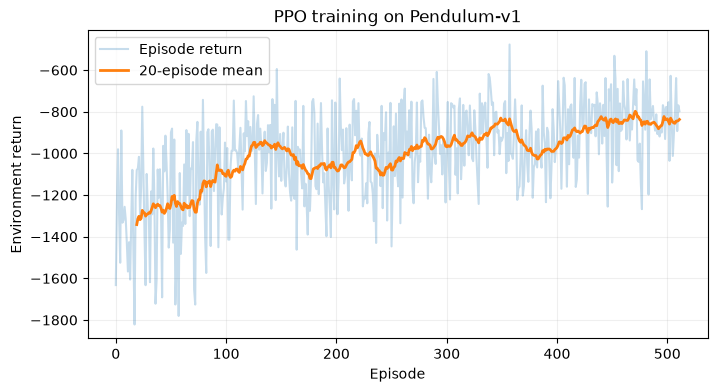

In [10]:
ppo_config = PPOConfig()

ppo_result = train_ppo(ppo_config)
torch.save(
    {
        "algorithm": "PPO",
        "environment": "Pendulum-v1",
        "config": asdict(ppo_config),
        "agent_state_dict": ppo_result.agent.state_dict(),
    },
    ARTIFACT_DIR / "pendulum_ppo.pt",
)

print(
    f"PPO finished {ppo_result.environment_steps:,} steps in "
    f"{ppo_result.elapsed_seconds:.1f} s on {model_device(ppo_result.agent)}"
)
print(f"Peak PyTorch GPU memory: {ppo_result.peak_memory_mib:.1f} MiB")
print("Saved:", ARTIFACT_DIR / "pendulum_ppo.pt")

if len(ppo_result.episode_returns):
    window = min(20, len(ppo_result.episode_returns))
    smooth = np.convolve(
        ppo_result.episode_returns,
        np.ones(window) / window,
        mode="valid",
    )
    plt.figure(figsize=(8, 4))
    plt.plot(
        ppo_result.episode_returns,
        alpha=0.25,
        label="Episode return",
    )
    plt.plot(
        np.arange(window - 1, len(ppo_result.episode_returns)),
        smooth,
        linewidth=2,
        label=f"{window}-episode mean",
    )
    plt.title("PPO training on Pendulum-v1")
    plt.xlabel("Episode")
    plt.ylabel("Environment return")
    plt.grid(alpha=0.2)
    plt.legend()
    plt.show()


## 6. Pendulum Evaluation

Evaluation makes no parameter updates and uses the deterministic transformed mean action. The quantitative function returns one number per episode: the sum of unmodified rewards emitted by `Pendulum-v1`. It does not compute a custom score, success rate, episode-length statistic, or entropy diagnostic. Afterward, one separately seeded deterministic rollout is rendered as a looping GIF.


In [11]:
def evaluate_pendulum_ppo(actor, episodes=10, seed=10_000):
    device = require_amd_gpu(model_device(actor))
    returns = np.zeros(episodes, dtype=float)
    actor.eval()

    for episode in range(episodes):
        episode_seed = seed + episode
        env = make_pendulum(episode_seed)
        observation, _ = env.reset(seed=episode_seed)
        episode_return = 0.0
        episode_done = False

        while not episode_done:
            observation_tensor = torch.as_tensor(
                observation,
                dtype=torch.float32,
                device=device,
            ).unsqueeze(0)
            with torch.inference_mode():
                action = actor.act(
                    observation_tensor, deterministic=True
                )
            observation, reward, terminated, truncated, _ = env.step(
                action.squeeze(0).cpu().numpy()
            )
            episode_return += float(reward)
            episode_done = bool(terminated or truncated)

        returns[episode] = episode_return
        env.close()
    return returns


ppo_evaluation_returns = evaluate_pendulum_ppo(
    ppo_result.agent.actor,
    episodes=10,
)
print(
    "Pendulum-v1 environment returns:",
    np.round(ppo_evaluation_returns, 2),
)
print(
    "Mean environment return:",
    round(float(ppo_evaluation_returns.mean()), 2),
)


Pendulum-v1 environment returns: [-644.74 -768.4  -741.13 -584.75 -807.22 -770.48 -846.32 -802.95 -778.25
 -597.84]
Mean environment return: -734.21


### 6.1 Looping Pendulum evaluation rollout

Following the DRL01 visualization pattern, the multi-episode evaluation above stays render-free. This cell records one additional deterministic episode with `render_mode="rgb_array"`, keeps the initial and terminal frames, and saves `loop=0` for infinite playback. Capturing every second control step and playing at 10 fps preserves the environment's real-time speed while reducing GIF memory.


Pendulum GIF environment return: -687.53
Saved looping GIF: artifacts/DRL05/pendulum_ppo_evaluation.gif


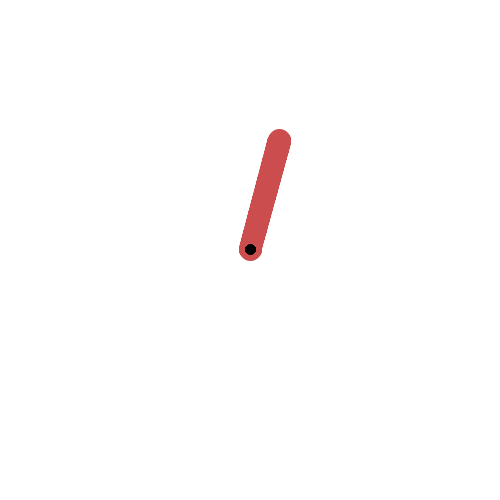

In [12]:
def record_pendulum_evaluation_gif(
    actor,
    path,
    seed=19_000,
    frame_stride=2,
):
    if frame_stride < 1:
        raise ValueError("frame_stride must be a positive integer.")
    device = require_amd_gpu(model_device(actor))
    env = make_pendulum(seed, render_mode="rgb_array")
    frames = []
    episode_return = 0.0
    episode_done = False
    step = 0
    actor.eval()

    try:
        observation, _ = env.reset(seed=seed)
        frames.append(env.render().copy())
        while not episode_done:
            observation_tensor = torch.as_tensor(
                observation,
                dtype=torch.float32,
                device=device,
            ).unsqueeze(0)
            with torch.inference_mode():
                action = actor.act(
                    observation_tensor, deterministic=True
                )
            observation, reward, terminated, truncated, _ = env.step(
                action.squeeze(0).cpu().numpy()
            )
            episode_return += float(reward)
            episode_done = bool(terminated or truncated)
            step += 1
            if step % frame_stride == 0 or episode_done:
                frames.append(env.render().copy())
    finally:
        env.close()

    imageio.mimsave(path, frames, fps=10, loop=0)
    return episode_return


pendulum_gif_path = ARTIFACT_DIR / "pendulum_ppo_evaluation.gif"
pendulum_gif_return = record_pendulum_evaluation_gif(
    ppo_result.agent.actor,
    pendulum_gif_path,
)
print("Pendulum GIF environment return:", round(pendulum_gif_return, 2))
print("Saved looping GIF:", pendulum_gif_path)
display(NotebookImage(filename=str(pendulum_gif_path)))


## 7. From PPO to Soft Actor-Critic

PPO and SAC can share the squashed Gaussian policy, but they learn from different data and critics.

| Property | PPO | SAC |
|---|---|---|
| Data | Fresh on-policy rollout | Uniform replay of past transitions |
| Critic | $V(s)$ | Twin $Q(s,a)$ networks |
| Update control | Probability-ratio clipping | Target critics and Polyak averaging |
| Exploration | Entropy bonus in the PPO loss | Entropy inside the Bellman target and actor loss |
| Data reuse | A few epochs, then discard rollout | Many random replay minibatches |

SAC's replay makes it a natural next step for the more expensive Walker Run environment: each collected transition can support multiple learning decisions over time.


## 8. Why Soft Actor-Critic?

Standard reinforcement learning maximizes expected discounted reward. SAC instead maximizes a **maximum-entropy** objective:

$$
J(\pi)=\mathbb E_{\tau\sim\pi}\left[
\sum_t\gamma^t
\left(r_t-\alpha\log\pi(a_t\mid s_t)\right)
\right].
$$

Because

$$
\mathcal H(\pi(\cdot\mid s))
=-\mathbb E_{a\sim\pi}[\log\pi(a\mid s)],
$$

the second term rewards policies that retain several plausible actions instead of collapsing too early to one behavior. The temperature $\alpha>0$ sets the relative scale of task reward and entropy. “Soft” refers to this entropy-regularized value learning—not to a softmax action layer.

During training, SAC samples stochastic actions. During evaluation, this tutorial uses $\tanh(\mu(s))$, the conventional deterministic action. Modern SAC uses twin $Q$ networks and automatic temperature tuning; unlike the earliest SAC formulation, it does not require a separately parameterized $V$ network.


### 8.1 Soft values and the Bellman backup

For a fixed policy, the soft state value is

$$
V^\pi(s)=\mathbb E_{a\sim\pi}
\left[Q^\pi(s,a)-\alpha\log\pi(a\mid s)\right].
$$

Substituting it into the Bellman equation gives

$$
Q^\pi(s,a)=\mathbb E
\left[r+\gamma d_{\mathrm{env}}V^\pi(s')\right].
$$

The implementation draws one next action from the online actor and uses the smaller of two target-critic estimates:

$$
a'\sim\pi_\theta(\cdot\mid s'),
$$

$$
y=r+\gamma d_{\mathrm{env}}
\left[
\min_{i\in\{1,2\}}Q_{\bar\phi_i}(s',a')
-\alpha\log\pi_\theta(a'\mid s')
\right].
$$

Each online critic minimizes

$$
J_Q(\phi_i)=\mathbb E_{\mathcal D}
\left[
\left(Q_{\phi_i}(s,a)-\operatorname{stopgrad}(y)\right)^2
\right].
$$

DeepMind Control supplies $d_{\mathrm{env}}$. Walker Run's time-limit transition requests a reset with `last()==True` but retains `discount==1.0`, so it still bootstraps. The target belongs inside `torch.no_grad()`. SAC has target critics, but the next action always comes from the current online actor.


In [13]:
reward = 0.4
gamma = 0.99
environment_discount = 1.0
target_q_1 = 7.2
target_q_2 = 6.8
next_log_probability = -1.5
alpha = 0.2

clipped_target_q = min(target_q_1, target_q_2)
soft_next_value = (
    clipped_target_q - alpha * next_log_probability
)
bellman_target = (
    reward
    + gamma * environment_discount * soft_next_value
)

print("Clipped target Q:", clipped_target_q)
print("Soft next value:", soft_next_value)
print("Bellman target:", bellman_target)
print("Zero-discount target:", reward)


Clipped target Q: 6.8
Soft next value: 7.1
Bellman target: 7.429
Zero-discount target: 0.4


### 8.2 Uniform replay, twin critics, and target critics

Replay changes the learning problem from PPO's fresh rollout to an off-policy dataset $\mathcal D$. Each transition stores raw CPU arrays $(s,a,r,s',d_{\mathrm{env}})$. Once the buffer contains enough coverage, a uniformly sampled minibatch moves to the AMD GPU. The ring buffer overwrites its oldest transition only after reaching capacity.

A one-million-entry Walker buffer stores $24+6+1+24+1=56$ `float32` values per transition: about 214 MiB of host memory. A 10,000-step random warm-up improves initial action coverage before the actor controls collection.

A single approximate critic can become optimistically biased. SAC initializes two independent critics, trains both on the same target, and uses the lower prediction in both the target and actor objectives. Target critics provide a slowly moving bootstrap reference:

$$
\bar\phi\leftarrow(1-\tau)\bar\phi+\tau\phi.
$$

With $\tau=0.005$, every update mixes 0.5% of each online parameter into its target counterpart.


In [14]:
class ReplayBuffer:
    def __init__(
        self,
        observation_dim,
        action_dim,
        capacity,
        seed,
    ):
        self.capacity = int(capacity)
        self.observations = np.empty(
            (capacity, observation_dim), dtype=np.float32
        )
        self.actions = np.empty(
            (capacity, action_dim), dtype=np.float32
        )
        self.rewards = np.empty((capacity, 1), dtype=np.float32)
        self.next_observations = np.empty(
            (capacity, observation_dim), dtype=np.float32
        )
        self.discounts = np.empty((capacity, 1), dtype=np.float32)
        self.position = 0
        self.size = 0
        self.rng = np.random.default_rng(seed)

    def add(
        self,
        observation,
        action,
        reward,
        next_observation,
        discount,
    ):
        index = self.position
        self.observations[index] = observation
        self.actions[index] = action
        self.rewards[index] = reward
        self.next_observations[index] = next_observation
        self.discounts[index] = discount
        self.position = (self.position + 1) % self.capacity
        self.size = min(self.size + 1, self.capacity)

    def sample(self, batch_size, device):
        indices = self.rng.integers(0, self.size, batch_size)
        arrays = (
            self.observations[indices],
            self.actions[indices],
            self.rewards[indices],
            self.next_observations[indices],
            self.discounts[indices],
        )
        return tuple(
            torch.as_tensor(array, device=device) for array in arrays
        )


bytes_per_transition = (24 + 6 + 1 + 24 + 1) * np.dtype(np.float32).itemsize
replay_mib = bytes_per_transition * 1_000_000 / 2**20
print(f"One-million-transition replay allocation: {replay_mib:.1f} MiB")


One-million-transition replay allocation: 213.6 MiB


### 8.3 Actor and critic network roles

The actor maps `24 → 256 → 256` features to separate six-dimensional mean and log-standard-deviation heads. Each critic concatenates the 24 observations and six actions, then maps `30 → 256 → 256 → 1`. The two critics share no weights. Their target copies begin identical to the online critics and are never optimized directly.

| Quantity | Network used |
|---|---|
| Collected action | Random warm-up, then online stochastic actor |
| Bellman target action | Online stochastic actor |
| Bellman target values | Twin target critics |
| Replay-action values | Twin online critics |
| Actor objective values | Twin online critics |


In [15]:
class TwinCritic(nn.Module):
    def __init__(
        self,
        observation_dim,
        action_dim,
        hidden_dims=(256, 256),
    ):
        super().__init__()
        input_dim = observation_dim + action_dim
        self.q_1 = make_mlp(
            input_dim, hidden_dims, 1, activation=nn.ReLU
        )
        self.q_2 = make_mlp(
            input_dim, hidden_dims, 1, activation=nn.ReLU
        )

    def forward(self, observation, action):
        features = torch.cat((observation, action), dim=-1)
        return self.q_1(features), self.q_2(features)


### 8.4 Reparameterized policy improvement

SAC reuses the bounded actor introduced for PPO, but its objective is different:

$$
J_\pi(\theta)=\mathbb E_{s\sim\mathcal D,\epsilon}
\left[
\alpha\log\pi_\theta(a\mid s)
-\min_iQ_{\phi_i}(s,a)
\right],
$$

$$
u=\mu_\theta(s)+\sigma_\theta(s)\odot\epsilon,
\qquad a=b+c\odot\tanh(u).
$$

The transformed density is

$$
\log\pi(a\mid s)=\sum_i\left[
\log\mathcal N(u_i;\mu_i,\sigma_i)
-\log c_i-\log(1-\tanh^2u_i)
\right].
$$

`rsample()` implements this pathwise gradient. During the actor step, critic parameters are frozen, but $\partial Q(s,a)/\partial a$ remains in the graph so the action gradient reaches the actor. Clamping `log_std` prevents extreme variances, and the log probability sums all six actuator dimensions. The deterministic evaluation action $\tanh(\mu)$ is a convention; it is not generally the exact mean of the squashed distribution.

### 8.5 Automatic entropy temperature

Rather than hand-tuning the reward–entropy scale, SAC learns it toward target entropy $\bar{\mathcal H}=-|\mathcal A|=-6$. The code optimizes $\beta=\log\alpha$, which guarantees $\alpha=e^\beta>0$, with the detached policy statistic

$$
J(\beta)=-\mathbb E\left[
\beta\,\operatorname{stopgrad}
(\log\pi(a\mid s)+\bar{\mathcal H})
\right].
$$

When exploration is below its target, optimization raises $\alpha$ and makes entropy more valuable; when it is above target, $\alpha$ falls. Continuous policies use differential entropy, so a negative target is not contradictory. The alpha loss must not update the actor, and the actor loss treats alpha as detached.


## 9. One SAC Update, in Order

One replay minibatch triggers five coordinated operations:

1. The online actor samples $a'$ at the stored next observations; target critics build a detached soft Bellman target.
2. Both online critics regress their replay-action predictions toward that target.
3. Critic weights are frozen while a reparameterized actor action is optimized against the smaller online-critic value.
4. `log_alpha` is updated from a detached log-probability statistic.
5. Every target-critic parameter receives a Polyak update.

The ordering prevents gradients from leaking into targets or into the wrong optimizer while retaining the necessary action gradient through the online critics.


In [16]:
def sac_update(
    batch,
    actor,
    critic,
    target_critic,
    actor_optimizer,
    critic_optimizer,
    log_alpha,
    alpha_optimizer,
    gamma,
    tau,
    target_entropy,
):
    observations, actions, rewards, next_observations, discounts = batch
    alpha = log_alpha.exp()

    with torch.no_grad():
        next_actions, next_log_probabilities, _ = actor.sample(
            next_observations
        )
        next_q_1, next_q_2 = target_critic(
            next_observations, next_actions
        )
        next_q = torch.minimum(next_q_1, next_q_2)
        target = rewards + gamma * discounts * (
            next_q - alpha.detach() * next_log_probabilities.unsqueeze(-1)
        )

    q_1, q_2 = critic(observations, actions)
    critic_loss = F.mse_loss(q_1, target) + F.mse_loss(q_2, target)
    critic_optimizer.zero_grad(set_to_none=True)
    critic_loss.backward()
    critic_optimizer.step()

    critic.requires_grad_(False)
    sampled_actions, log_probabilities, _ = actor.sample(observations)
    policy_q_1, policy_q_2 = critic(observations, sampled_actions)
    policy_q = torch.minimum(policy_q_1, policy_q_2)
    actor_loss = (
        alpha.detach() * log_probabilities.unsqueeze(-1) - policy_q
    ).mean()
    actor_optimizer.zero_grad(set_to_none=True)
    actor_loss.backward()
    actor_optimizer.step()
    critic.requires_grad_(True)

    alpha_loss = -(
        log_alpha
        * (log_probabilities + target_entropy).detach()
    ).mean()
    alpha_optimizer.zero_grad(set_to_none=True)
    alpha_loss.backward()
    alpha_optimizer.step()

    with torch.no_grad():
        for online_parameter, target_parameter in zip(
            critic.parameters(), target_critic.parameters()
        ):
            target_parameter.mul_(1 - tau).add_(
                online_parameter, alpha=tau
            )

    policy_entropy = -log_probabilities.mean()
    return (
        critic_loss.detach(),
        actor_loss.detach(),
        log_alpha.exp().detach(),
        policy_entropy.detach(),
    )


## 10. Walker Run Training for 1,000,000 Steps

The configuration always completes one million environment interactions. There is no wall-clock deadline or time-based `break`; elapsed time is measured only after the final step.

| Setting | Value | Meaning |
|---|---:|---|
| Environment steps | 1,000,000 | Full default interaction budget |
| Replay capacity | 1,000,000 | Retains the full training history |
| Random warm-up | 10,000 | Initial action-space coverage |
| Batch size | 256 | Transitions per AMD GPU update |
| Updates per step | 1 | One update after each later interaction |
| Discount $\gamma$ | 0.99 | Multiplies the DMC transition discount |
| Polyak $\tau$ | 0.005 | Target-critic mixing rate |
| Learning rate | $3\times10^{-4}$ | Actor, critics, and temperature |
| Initial $\alpha$ | 0.1 | Initial entropy scale |
| Target entropy | -6 | Heuristic of -1 per actuator |

This baseline keeps observations raw so the replay-to-network data path stays explicit. The features are heterogeneous—orientations are bounded while velocities can reach tens—so normalization is a reasonable extension if learning becomes seed-sensitive. Any running statistics must then be checkpointed and applied unchanged during evaluation.


In [18]:
@dataclass
class SACConfig:
    total_environment_steps: int = 1_000_000
    replay_capacity: int = 1_000_000
    learning_starts: int = 10_000
    batch_size: int = 256
    hidden_dims: tuple = (256, 256)
    learning_rate: float = 3e-4
    gamma: float = 0.99
    tau: float = 0.005
    initial_alpha: float = 0.1
    print_every: int = 10_000


@dataclass
class SACResult:
    actor: nn.Module
    episode_returns: np.ndarray
    diagnostic_steps: np.ndarray
    critic_losses: np.ndarray
    actor_losses: np.ndarray
    alphas: np.ndarray
    policy_entropies: np.ndarray
    elapsed_seconds: float
    peak_memory_mib: float
    environment_steps: int
    final_alpha: float


In [19]:
def train_sac(config, seed=SEED, device=DEVICE):
    device = require_amd_gpu(device)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    env = WalkerRunEnvironment(seed)
    observation = env.reset()
    observation_dim = observation.size
    action_dim = env.action_low.size
    actor = SquashedGaussianActor(
        observation_dim,
        env.action_low,
        env.action_high,
        config.hidden_dims,
        state_dependent_std=True,
        activation=nn.ReLU,
    ).to(device)
    critic = TwinCritic(
        observation_dim, action_dim, config.hidden_dims
    ).to(device)
    target_critic = copy.deepcopy(critic).to(device)
    target_critic.requires_grad_(False)
    require_models_on_amd_gpu(actor, critic, target_critic)

    actor_optimizer = torch.optim.Adam(
        actor.parameters(), lr=config.learning_rate
    )
    critic_optimizer = torch.optim.Adam(
        critic.parameters(), lr=config.learning_rate
    )
    log_alpha = torch.tensor(
        math.log(config.initial_alpha),
        dtype=torch.float32,
        device=device,
        requires_grad=True,
    )
    alpha_optimizer = torch.optim.Adam(
        [log_alpha], lr=config.learning_rate
    )
    target_entropy = -float(action_dim)
    replay = ReplayBuffer(
        observation_dim,
        action_dim,
        config.replay_capacity,
        seed,
    )

    episode_returns = []
    diagnostic_steps = []
    critic_losses = []
    actor_losses = []
    alphas = []
    policy_entropies = []
    running_return = 0.0
    last_metrics = None
    interval_critic_loss = torch.zeros((), device=device)
    interval_actor_loss = torch.zeros((), device=device)
    interval_policy_entropy = torch.zeros((), device=device)
    interval_update_count = 0
    torch.cuda.reset_peak_memory_stats(device)
    torch.cuda.synchronize(device)
    started = time.perf_counter()
    completed_steps = 0

    for step in range(config.total_environment_steps):
        if step < config.learning_starts:
            action = env.sample_action()
        else:
            observation_tensor = torch.as_tensor(
                observation,
                dtype=torch.float32,
                device=device,
            ).unsqueeze(0)
            actor.eval()
            with torch.inference_mode():
                sampled_action = actor.act(
                    observation_tensor, deterministic=False
                )
            action = sampled_action.squeeze(0).cpu().numpy()

        (
            next_observation,
            reward,
            episode_done,
            bootstrap_discount,
        ) = env.step(action)
        replay.add(
            observation,
            action,
            reward,
            next_observation,
            bootstrap_discount,
        )
        running_return += reward
        observation = next_observation

        if episode_done:
            episode_returns.append(running_return)
            running_return = 0.0
            observation = env.reset()

        if step >= config.learning_starts and replay.size >= config.batch_size:
            actor.train()
            batch = replay.sample(config.batch_size, device)
            assert all(tensor.device == device for tensor in batch)
            last_metrics = sac_update(
                batch,
                actor,
                critic,
                target_critic,
                actor_optimizer,
                critic_optimizer,
                log_alpha,
                alpha_optimizer,
                config.gamma,
                config.tau,
                target_entropy,
            )
            interval_critic_loss += last_metrics[0]
            interval_actor_loss += last_metrics[1]
            interval_policy_entropy += last_metrics[3]
            interval_update_count += 1

        completed_steps = step + 1
        if completed_steps % config.print_every == 0:
            recent = episode_returns[-10:]
            recent_text = (
                f"{np.mean(recent):.1f}" if recent else "pending"
            )
            if interval_update_count:
                diagnostic_steps.append(completed_steps)
                critic_losses.append(
                    float(interval_critic_loss / interval_update_count)
                )
                actor_losses.append(
                    float(interval_actor_loss / interval_update_count)
                )
                alphas.append(float(last_metrics[2]))
                policy_entropies.append(
                    float(interval_policy_entropy / interval_update_count)
                )
                assert np.all(
                    np.isfinite(
                        (
                            critic_losses[-1],
                            actor_losses[-1],
                            alphas[-1],
                            policy_entropies[-1],
                        )
                    )
                ), "Non-finite SAC diagnostic detected."
                alpha_text = f"{alphas[-1]:.3f}"
                interval_critic_loss.zero_()
                interval_actor_loss.zero_()
                interval_policy_entropy.zero_()
                interval_update_count = 0
            else:
                alpha_text = "warming up"
            elapsed_minutes = (time.perf_counter() - started) / 60
            print(
                f"SAC step {completed_steps:>9,}/"
                f"{config.total_environment_steps:,} | "
                f"recent environment return={recent_text} | "
                f"alpha={alpha_text} | {elapsed_minutes:.1f} min"
            )

    torch.cuda.synchronize(device)
    elapsed_seconds = time.perf_counter() - started
    peak_memory_mib = torch.cuda.max_memory_allocated(device) / 2**20
    final_alpha = float(log_alpha.exp().detach())
    env.close()
    return SACResult(
        actor=actor,
        episode_returns=np.asarray(episode_returns, dtype=float),
        diagnostic_steps=np.asarray(diagnostic_steps, dtype=int),
        critic_losses=np.asarray(critic_losses, dtype=float),
        actor_losses=np.asarray(actor_losses, dtype=float),
        alphas=np.asarray(alphas, dtype=float),
        policy_entropies=np.asarray(policy_entropies, dtype=float),
        elapsed_seconds=elapsed_seconds,
        peak_memory_mib=peak_memory_mib,
        environment_steps=completed_steps,
        final_alpha=final_alpha,
    )


SAC step    10,000/1,000,000 | recent environment return=23.2 | alpha=warming up | 0.0 min


SAC step    20,000/1,000,000 | recent environment return=28.0 | alpha=0.005 | 0.6 min


SAC step    30,000/1,000,000 | recent environment return=41.2 | alpha=0.001 | 1.2 min


SAC step    40,000/1,000,000 | recent environment return=51.1 | alpha=0.001 | 1.7 min


SAC step    50,000/1,000,000 | recent environment return=79.2 | alpha=0.001 | 2.3 min


...

SAC step   960,000/1,000,000 | recent environment return=726.2 | alpha=0.007 | 56.8 min


SAC step   970,000/1,000,000 | recent environment return=726.6 | alpha=0.007 | 57.4 min


SAC step   980,000/1,000,000 | recent environment return=728.6 | alpha=0.007 | 58.0 min


SAC step   990,000/1,000,000 | recent environment return=728.6 | alpha=0.007 | 58.6 min


SAC step 1,000,000/1,000,000 | recent environment return=727.9 | alpha=0.007 | 59.2 min
SAC completed all 1,000,000 steps in 59.2 min
Final entropy temperature: 0.0073
Peak PyTorch GPU memory: 146.0 MiB
Saved: artifacts/DRL05/walker_run_sac.pt


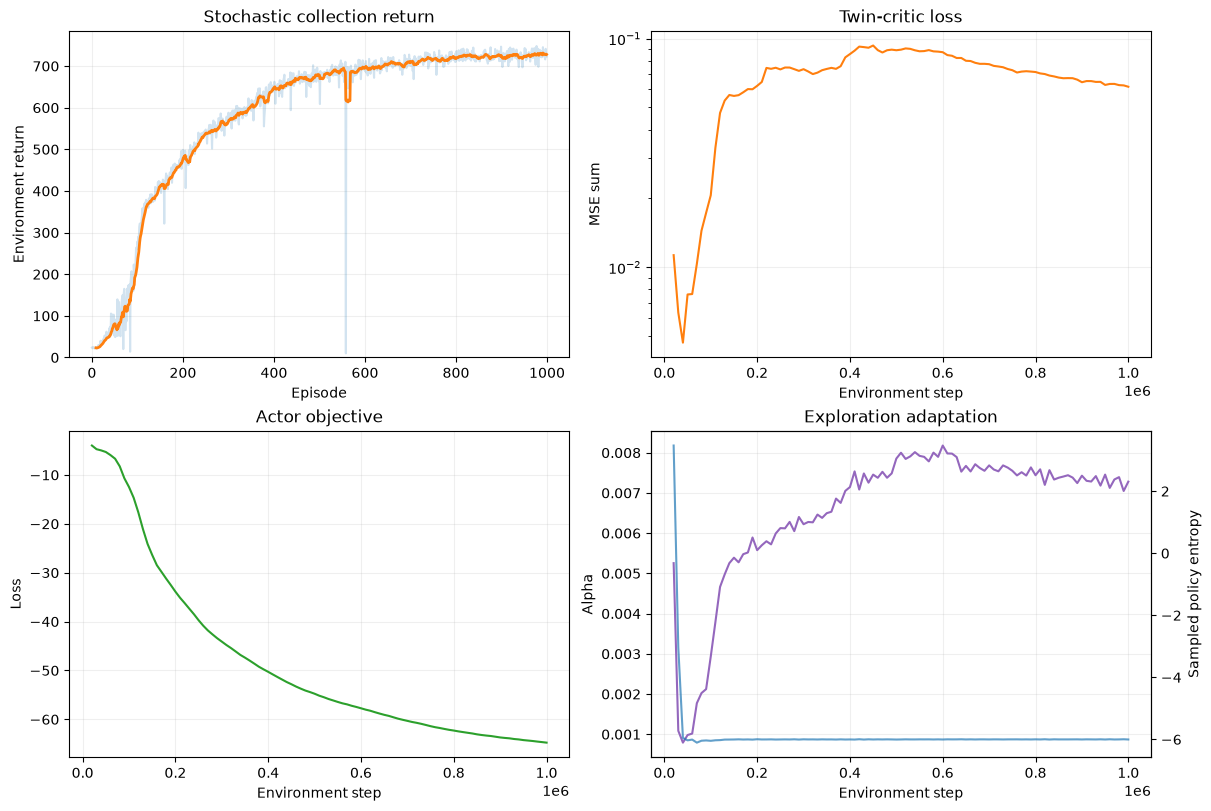

In [20]:
sac_config = SACConfig()

sac_result = train_sac(sac_config)
torch.save(
    {
        "algorithm": "SAC",
        "environment": "dm_control/walker-run",
        "config": asdict(sac_config),
        "actor_state_dict": sac_result.actor.state_dict(),
    },
    ARTIFACT_DIR / "walker_run_sac.pt",
)

assert sac_result.environment_steps == sac_config.total_environment_steps
print(
    f"SAC completed all {sac_result.environment_steps:,} steps in "
    f"{sac_result.elapsed_seconds / 60:.1f} min"
)
print(f"Final entropy temperature: {sac_result.final_alpha:.4f}")
print(f"Peak PyTorch GPU memory: {sac_result.peak_memory_mib:.1f} MiB")
print("Saved:", ARTIFACT_DIR / "walker_run_sac.pt")

figure, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
if len(sac_result.episode_returns):
    window = min(10, len(sac_result.episode_returns))
    smooth = np.convolve(
        sac_result.episode_returns,
        np.ones(window) / window,
        mode="valid",
    )
    axes[0, 0].plot(sac_result.episode_returns, alpha=0.2)
    axes[0, 0].plot(
        np.arange(window - 1, len(sac_result.episode_returns)),
        smooth,
        linewidth=2,
    )
axes[0, 0].set_title("Stochastic collection return")
axes[0, 0].set_xlabel("Episode")
axes[0, 0].set_ylabel("Environment return")
axes[0, 0].set_ylim(bottom=0)

axes[0, 1].plot(
    sac_result.diagnostic_steps,
    sac_result.critic_losses,
    color="tab:orange",
)
axes[0, 1].set_title("Twin-critic loss")
axes[0, 1].set_xlabel("Environment step")
axes[0, 1].set_ylabel("MSE sum")
if np.all(sac_result.critic_losses > 0):
    axes[0, 1].set_yscale("log")

axes[1, 0].plot(
    sac_result.diagnostic_steps,
    sac_result.actor_losses,
    color="tab:green",
)
axes[1, 0].set_title("Actor objective")
axes[1, 0].set_xlabel("Environment step")
axes[1, 0].set_ylabel("Loss")

axes[1, 1].plot(
    sac_result.diagnostic_steps,
    sac_result.alphas,
    color="tab:purple",
    label="Alpha",
)
axes[1, 1].set_title("Exploration adaptation")
axes[1, 1].set_xlabel("Environment step")
axes[1, 1].set_ylabel("Alpha")
entropy_axis = axes[1, 1].twinx()
entropy_axis.plot(
    sac_result.diagnostic_steps,
    sac_result.policy_entropies,
    color="tab:blue",
    alpha=0.7,
    label="Policy entropy",
)
entropy_axis.set_ylabel("Sampled policy entropy")

for axis in axes.flat:
    axis.grid(alpha=0.2)
plt.show()


## 11. Walker Run Evaluation

The final actor uses its deterministic transformed mean. Each quantitative evaluation environment is constructed with a distinct fixed seed, and the only reported metric is the 1,000-step sum of original Walker Run rewards. There is no reward shaping, custom score, displacement metric, or episode-length metric. One additional deterministic rollout is then rendered solely as a qualitative, infinitely looping GIF.


In [21]:
def evaluate_walker_sac(actor, episodes=10, seed=20_000):
    device = require_amd_gpu(model_device(actor))
    returns = np.zeros(episodes, dtype=float)
    actor.eval()

    for episode in range(episodes):
        env = WalkerRunEnvironment(seed + episode)
        observation = env.reset()
        episode_return = 0.0
        episode_done = False

        while not episode_done:
            observation_tensor = torch.as_tensor(
                observation,
                dtype=torch.float32,
                device=device,
            ).unsqueeze(0)
            with torch.inference_mode():
                action = actor.act(
                    observation_tensor, deterministic=True
                )
            observation, reward, episode_done, _ = env.step(
                action.squeeze(0).cpu().numpy()
            )
            episode_return += reward

        returns[episode] = episode_return
        env.close()
    return returns


sac_evaluation_returns = evaluate_walker_sac(
    sac_result.actor,
    episodes=10,
)
print(
    "Walker Run environment returns:",
    np.round(sac_evaluation_returns, 2),
)
print(
    "Mean environment return:",
    round(float(sac_evaluation_returns.mean()), 2),
)


Walker Run environment returns: [734.57 731.24 741.32 749.99 719.42 747.01 733.16 739.24 740.35 730.47]
Mean environment return: 736.68


### 11.1 Looping Walker Run evaluation rollout

Walker Run lasts 1,000 control steps. Capturing a 320×240 frame every fourth step produces 251 frames and plays at 10 fps, matching the original 0.025-second control timestep while avoiding a thousand-frame GIF. The initial and terminal frames are always retained. `loop=0` makes the animation repeat indefinitely.

When `MUJOCO_GL=egl` is explicitly selected before kernel startup and EGL succeeds, frames come from MuJoCo's tracked `side` camera. Otherwise the adapter draws the same physical body positions as a portable 2-D kinematic view, so the tutorial still produces an evaluation animation in minimal containers.


Walker GIF environment return: 727.92
Walker GIF renderer: portable 2-D
Saved looping GIF: artifacts/DRL05/walker_run_sac_evaluation.gif


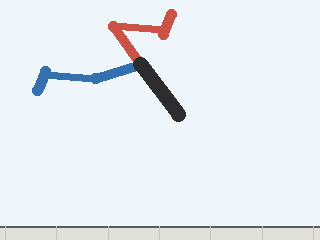

In [22]:
def record_walker_evaluation_gif(
    actor,
    path,
    seed=29_000,
    frame_stride=4,
):
    if frame_stride < 1:
        raise ValueError("frame_stride must be a positive integer.")
    device = require_amd_gpu(model_device(actor))
    env = WalkerRunEnvironment(seed)
    frames = []
    episode_return = 0.0
    episode_done = False
    step = 0
    actor.eval()

    try:
        observation = env.reset()
        frames.append(env.render(height=240, width=320))
        while not episode_done:
            observation_tensor = torch.as_tensor(
                observation,
                dtype=torch.float32,
                device=device,
            ).unsqueeze(0)
            with torch.inference_mode():
                action = actor.act(
                    observation_tensor, deterministic=True
                )
            observation, reward, episode_done, _ = env.step(
                action.squeeze(0).cpu().numpy()
            )
            episode_return += reward
            step += 1
            if step % frame_stride == 0 or episode_done:
                frames.append(env.render(height=240, width=320))
        render_backend = env.render_backend
    finally:
        env.close()

    imageio.mimsave(path, frames, fps=10, loop=0)
    return episode_return, render_backend


walker_gif_path = ARTIFACT_DIR / "walker_run_sac_evaluation.gif"
walker_gif_return, walker_gif_backend = record_walker_evaluation_gif(
    sac_result.actor,
    walker_gif_path,
)
print("Walker GIF environment return:", round(walker_gif_return, 2))
print("Walker GIF renderer:", walker_gif_backend)
print("Saved looping GIF:", walker_gif_path)
display(NotebookImage(filename=str(walker_gif_path)))


## 12. Where the AMD GPU Is Used

The `torch.cuda` namespace is intentional: ROCm PyTorch exposes AMD GPUs through this CUDA-compatible API. The additional `torch.version.hip` check distinguishes a ROCm build from an NVIDIA CUDA build.

| Work | Location | Runtime evidence |
|---|---|---|
| Gymnasium and MuJoCo `step()` / `reset()` | CPU | NumPy observations and actions cross the environment boundary |
| PPO actor, value function, GAE, ratios, losses, gradients | AMD GPU | Trainer rejects non-ROCm devices and asserts the rollout batch device |
| SAC actor, twin critics, targets, replay minibatches, losses, gradients | AMD GPU | Trainer checks every model and sampled replay tensor |
| GIF encoding and optional portable rendering | CPU | Evaluation frames become RGB arrays for ImageIO |
| Timing and memory | Synchronized AMD GPU | `torch.cuda.synchronize` brackets elapsed time; peak allocation is reported |

Sequential simulation can still be the throughput bottleneck. GPU acceleration applies to neural computation; it does not turn the environment itself into a GPU simulator. The one-million-step SAC loop measures elapsed time but never uses it as a stopping condition.


## Conclusions

In this lab, you completed two complementary approaches to bounded continuous control:

- Implemented a correctly transformed Gaussian policy shared by PPO and SAC
- Used clipped probability ratios, a learned state value, and GAE in PPO
- Trained and evaluated PPO on Gymnasium Pendulum
- Derived SAC from soft values through its sampled Bellman target
- Reused experience with a one-million-entry replay buffer
- Applied clipped double-Q learning and Polyak target critics
- Applied reparameterized actor gradients and automatic temperature tuning
- Trained SAC for a complete one million Walker Run interactions
- Preserved correct bootstrapping at Gymnasium and DeepMind Control time limits
- Enforced AMD ROCm execution without a CPU fallback
- Kept quantitative evaluation focused exclusively on original environment return
- Produced deterministic Pendulum and Walker Run GIFs with infinite playback

PPO is often attractive when fresh parallel rollouts are readily available; SAC is attractive when environment interactions should be reused. The shared action transform makes their different objectives, data flows, and critics directly comparable.


---

Copyright (C) 2026 Advanced Micro Devices, Inc. All rights reserved. Portions of this file consist of AI-generated content.  
SPDX-License-Identifier: MIT
